# I - Perkenalan

Nama  : Revi Naufal Hisyam </br>
Batch : RMT - 039

Objective: Dataset ini `Churn_Modelling.csv` memiliki ukuran 14 kolom dan 10,000 baris tanpa duplikasi dan missing value. Penggunaan dataset ini adalah karna saya ingin melakukan prediksi untuk mengetahui nasabah mana yang akan menutup akun atau bertahan, agar kemudian dapat di lakukan upaya maksimal dan efisien.

## SMART Framework
- Specific
Menaikan pendapatan dengan mempertahankan lebih banyak customer / customer retention rate.
- Measurable
Mengurangi tingkat kepergian customer sebanyak 50%.
- Achievable
Mendapatkan insight paling baik dari analisa yang dilakukan terhadap dataset ini.
- Relevant
Memastikan pendekatan terbaik yang di gunakan oleh tim marketing, kepada para customer.
- Time-bound
Diharapkan hasil Analisa ini selesai dengan cepat, agar pada quarter selanjutnya strategi dari tim marketing sudah siap untuk di jalankan.


## Conceptual problems
- Jelaskan latar belakang adanya bagging beserta cara kerjanya
- jelaskan cara kerja algoritma Random Forest dan algoritma boosting yang anda pilih
- jelaskan apa yang dimaksud dengan Cross Validation.

- 1.
Bagging, singkatan dari Bootstrap Aggregating, adalah metode ensemble learning yang digunakan untuk meningkatkan akurasi model pembelajaran mesin dengan cara menggabungkan hasil prediksi dari beberapa model dasar (base learners). Teknik ini pertama kali diperkenalkan oleh Leo Breiman pada tahun 1994 dan sering digunakan untuk mengurangi varians (variance) model dan mencegah overfitting.

- 2.1
Cara Kerja Algoritma Random Forest:
Random Forest adalah algoritma ensemble learning yang menggunakan teknik bagging (Bootstrap Aggregating). Algoritma ini menggabungkan banyak pohon keputusan (decision trees) untuk menghasilkan model yang lebih stabil dan akurat.

- 2.2
Boosting adalah metode ensemble yang berfungsi dengan menggabungkan model-model sederhana (base learners) secara berurutan untuk meningkatkan akurasi model keseluruhan. Algoritma yang paling populer untuk boosting adalah AdaBoost (Adaptive Boosting).

- 3.
Cross Validation (CV) adalah teknik yang digunakan untuk mengevaluasi kinerja model pembelajaran mesin dengan cara membagi data menjadi beberapa bagian (folds) untuk pelatihan dan pengujian model secara bergantian. Tujuan utama dari cross-validation adalah untuk mengurangi overfitting dan memberikan gambaran yang lebih akurat.


# II - Import Libraries

In [2]:
pip install scikit-learn==1.5.2

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install feature_engine

Note: you may need to restart the kernel to use updated packages.


In [4]:
# Import library yang akan digunakan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import pickle
import json

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import f1_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from feature_engine.outliers import Winsorizer
from scipy.stats import pearsonr,kendalltau, pointbiserialr, f_oneway
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# III - Data Loading

In [5]:
# Loading dataset yang akan digunakan
df = pd.read_csv('Churn_Modelling.csv')
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [6]:
# Cek informasi data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [7]:
# Pengecekan jumlah nilai unik pada tiap kolom
df.nunique()

RowNumber          10000
CustomerId         10000
Surname             2932
CreditScore          460
Geography              3
Gender                 2
Age                   70
Tenure                11
Balance             6382
NumOfProducts          4
HasCrCard              2
IsActiveMember         2
EstimatedSalary     9999
Exited                 2
dtype: int64

In [8]:
# Drop kolom
df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1, inplace=True)

In [9]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


Kolom `RowNumber, CustomerId, dan Surname` memiliki variasi nilai unik yang sangat banyak, dan unik id seperti ini tidak relevan dengan target. Berbeda dengan `EstimatedSallary` yang memiliki variasi nilai unik yang banyak, namun akan memberikan pola untuk machine learning belajar.

In [10]:
# Cek Duplikasi
df.duplicated().sum()

0

Pada dataset yang digunakan kali ini, terdapat 10,000 baris dan 11 kolom `['CreditScore', 'Geography','Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard','IsActiveMember', 'EstimatedSalary', 'Exited']`. Dataset yang digunakan kali ini tidak memiliki missing value dan data yang terduplikasi, setiap baris data tersi dengan rapih.

# IV - Exploratory Data Analysis (EDA)

Pada bagian ini akan dilakukan explorasi data sederhana dengan menjawab persoalan, seperti :

- Berapa kah perbandingan jumlah `Balance` antara kedua `Gender`?
- Apakah ada korelasi antara usia dan customer yang menutup akun?
- Berapa rata-rata salary pada tiap region?

## Pertanyaan 1

Gender
Female    3.437205e+08
Male      4.211384e+08
Name: Balance, dtype: float64


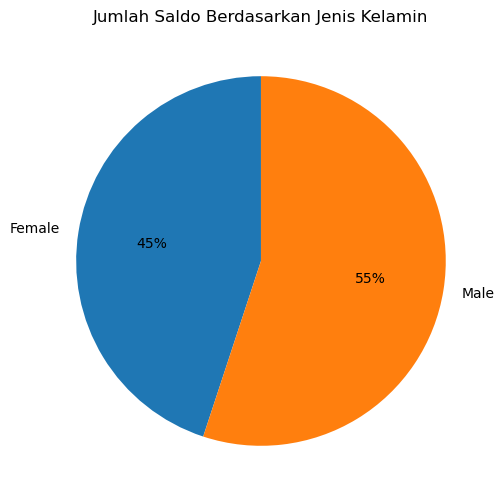

In [11]:
# Menjawab pertanyaan pertama
eda1 = df.groupby('Gender')['Balance'].sum()
plt.figure(figsize=(8, 6))
plt.pie(eda1, labels=eda1.index, autopct='%1.0f%%', startangle=90)
plt.title('Jumlah Saldo Berdasarkan Jenis Kelamin')
print(eda1)
plt.show()

Dari pie chart diatas, diketahui gender laki-laki memiliki saldo yang sedikit lebih banyak dibanding perempuan. Saldo dari gender laki-laki sebanyak 421,138,400 (55%) dan gender perempuan memiliki total saldo sebesar 343,720,500 (45%), selisih saldo antara kedua gender 77,417,900 (10%).

## Pertanyaan 2

Hipotesis untuk pertanyaan kedua dengan `alpha 0.05`:
- H0 : Tidak ada hubungan antara usia dan penutupan akun
- H1 : Ada hubungan antara usia dan penutupan akun

In [12]:
# Menjawab Pertanyaan Kedua Menggunakan metode Point-Biserial
correlation_pb, p_value_pb = stats.pointbiserialr(df['Age'], df['Exited'])
print(f"Point-Biserial Correlation: {correlation_pb:.2f}, p-value: {p_value_pb}")

Point-Biserial Correlation: 0.29, p-value: 1.2399313093415674e-186


In [13]:
# Menjawab Pertanyaan Kedua Menggunakan metode Pearson
corr_r, pval_p = stats.pearsonr(df['Age'], df['Exited'])
print(f"r-correlation: {corr_r:.2f}, p-value: {pval_p}")

r-correlation: 0.29, p-value: 1.2399313093415674e-186


Menjawab pertanyaan ini menggunakan 2 metode uji korelasi sebagai perbandingan antara metode pearson dan point-biserial. Penggunaan  uji korelasi Point Biserial digunakan untuk mengukur hubungan antara satu variabel yang berskala interval atau rasio dengan satu variabel dikotomi (dua kategori) yang berskala nominal. Metode ini juga merupakan teknik statistik nonparametrik dan sering digunakan dalam konteks pengujian validitas item dalam tes. Koefisien korelasi Point Biserial juga berkisar antara -1 hingga 1, dengan interpretasi yang mirip dengan koefisien korelasi Pearson.

Pada uji korelasi diatas antara kolom `Age` dan `Exited`, di dapati nilai r-correlation sebesar 0.29 menunjukan adanya korelasi positif yang cukup lemah, sehingga hanya memiliki sedikit kemungkinan bahwa customer dengan usia lebih tua untuk menutup akun bank. Sedangkan untuk p-value yang bahkan tidak mencapai 0.01 atau kurang dari 0.05, `yang menyatakn bahwa H0 gagal di tolak` yang berarti tidak ada hubungan antara usia dan penutupan akun bank.

## Pertanyaan 3

Hipotesis untuk pertanyaan ketiga dengan `alpha 0.05`:
- H0 : Tidak ada perbedaan rata-rata Estimated Salary di antara kelompok Geography yang berbeda.
- H1 : Ada setidaknya satu kelompok Geography yang memiliki rata-rata Estimated Salary yang berbeda.

In [14]:
# ANOVA Testing Untuk Pertanyaan Ketiga
eda3 = ['France', 'Spain', 'Germany']
eda33 = df[df['Geography'].isin(eda3)]
eda333 = [df['EstimatedSalary'].values for _, df in eda33.groupby('Geography')]
eda3_anova = f_oneway(*eda333)
print("F-statistic  :", eda3_anova.statistic)
print("P-value      :", eda3_anova.pvalue)

F-statistic  : 0.5827609114534064
P-value      : 0.5583736355799094


Geography
France      99899.180814
Germany    101113.435102
Spain       99440.572281
Name: EstimatedSalary, dtype: float64


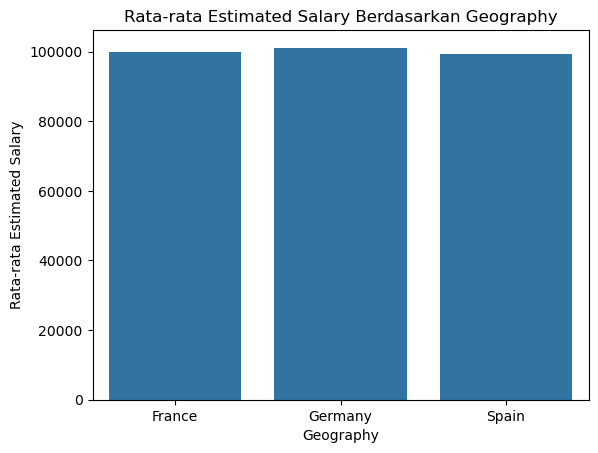

In [15]:
# Pengecekan Nilai Estimated Salary pada tiap Geography
mmeeaann = df.groupby('Geography')['EstimatedSalary'].mean()
print(mmeeaann)
sns.barplot(x=mmeeaann.index, y=mmeeaann.values)
plt.title('Rata-rata Estimated Salary Berdasarkan Geography')
plt.xlabel('Geography')
plt.ylabel('Rata-rata Estimated Salary')
plt.show()

Dari hasil hipotesis testing menggunakan ANOVA untuk menjawab pertanyaan ketiga, di dapati nilai p-value sebesar 0.55 yang menyatakan bahwa H0 di tolak menandakan bahwa ada setidaknya satu kelompok Geography yang memiliki rata-rata Estimated Salary yang berbeda. Jika dilihat pada visualisasi data memang nilai average pada Germany sedikit lebih tinggi di banding 2 negara lainnya.

# V - Feature Engineering

## Splitting data

In [16]:
# Splitting data X dan y
X = df.drop(["Exited"], axis=1)
y = df["Exited"]
X.head(10)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10
5,645,Spain,Male,44,8,113755.78,2,1,0,149756.71
6,822,France,Male,50,7,0.00,2,1,1,10062.80
7,376,Germany,Female,29,4,115046.74,4,1,0,119346.88
8,501,France,Male,44,4,142051.07,2,0,1,74940.50
9,684,France,Male,27,2,134603.88,1,1,1,71725.73


In [17]:
# Split kategorikal dan numerikal kolom
cat_cols = ["Geography", "Gender"]
num_cols = ["CreditScore", "Age", "Tenure", "Balance", "NumOfProducts", "HasCrCard", "IsActiveMember", "EstimatedSalary"]

Kategorikal dan Numerikal kolom sudah dipisahkan.

## Splitting train - test

In [18]:
#Splitting between train and test

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 40)
print('Train Size: ', X_train.shape)
print('Test Size: ', X_test.shape)

Train Size:  (8000, 10)
Test Size:  (2000, 10)


## MissVal Checking

In [19]:
# Cek MissVal
print(X_train.isnull().sum())
print(X_test.isnull().sum())

CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
dtype: int64
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
dtype: int64


## Outlier Checking & Handling

In [20]:
# Pengecekan outliers pada setiap numerikal kolom
skewness_info = X_train[num_cols].skew()
skewness_info

CreditScore       -0.079776
Age                1.022503
Tenure             0.019373
Balance           -0.156168
NumOfProducts      0.758823
HasCrCard         -0.909784
IsActiveMember    -0.059538
EstimatedSalary    0.001029
dtype: float64

Nilai skewness dari tiap kolom sangat bervariasi, ada yang normal, skew, hingga extreme. Selanjutnya akan di lakukan pembagian kategori berdasarkan nilai skewness.

In [21]:
# Pembuatan list kosong untuk pembagian kategori berdasar nilai skewness
normal_columns = []
skewed_columns = []
extreme_skewed_columns = []

# Loop through the skewness values and categorize the columns
for col, skewness in skewness_info.items():
    if skewness < -1.0 or skewness > 1.0:
        extreme_skewed_columns.append(col)
    elif abs(skewness) <= 0.5: # sama aja dgn -0.5 <= skewness <= 0.5
        normal_columns.append(col)
    else:
        skewed_columns.append(col)

# Print the columns in each category
print(f"Normal: {normal_columns}\nSkewed: {skewed_columns}\nExtreme Skewed: {extreme_skewed_columns}")

Normal: ['CreditScore', 'Tenure', 'Balance', 'IsActiveMember', 'EstimatedSalary']
Skewed: ['NumOfProducts', 'HasCrCard']
Extreme Skewed: ['Age']


### Boxplot sebelum capping

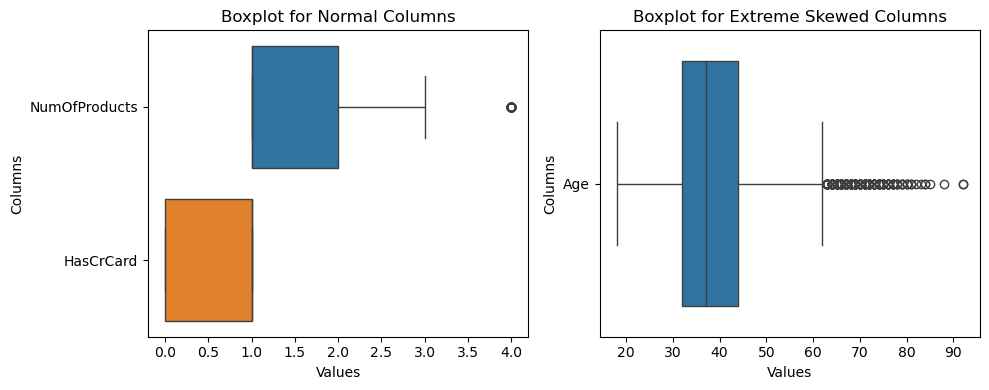

In [22]:
# Create a figure and two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(10, 4)) # menampilkan grafik 1 baris 2 kolom

# Boxplot for skewed columns
sns.boxplot(data=X_train[skewed_columns], orient="h", ax=axes[0])
axes[0].set_title("Boxplot for Normal Columns")
axes[0].set_xlabel("Values")
axes[0].set_ylabel("Columns")

# Boxplot for extreme skewed columns
sns.boxplot(data=X_train[extreme_skewed_columns], orient="h", ax=axes[1])
axes[1].set_title("Boxplot for Extreme Skewed Columns")
axes[1].set_xlabel("Values")
axes[1].set_ylabel("Columns")

# Display the plot
plt.tight_layout()
plt.show()

Dari pengecekan nilai skewness, telah dibagi 3 kategori berdasarkan nilai skewness `Normal, Skew, Extreme`. Tahap selanjutnya akan di lakukan capping method menggunakan winsorizer.

### Handling menggunakan capping method

In [23]:
# Capping outliers berdasarkan kategori dari nilai skewnessnya
normal_columns = ['CreditScore', 'Tenure', 'Balance', 'IsActiveMember', 'EstimatedSalary']
skewed_columns = ['NumOfProducts', 'HasCrCard']
extreme_skewed_columns = ['Age']

# Winsorizer untuk normal_columns
windsoriser1 = Winsorizer(capping_method='gaussian',
                          tail='both',
                          fold=3,
                          variables=normal_columns)

# Winsorizer untuk skewed_columns
windsoriser2 = Winsorizer(capping_method='iqr',
                          tail='both',
                          fold=1.5,
                          variables=skewed_columns)

# Winsorizer untuk extreme_skewed_columns
windsoriser3 = Winsorizer(capping_method='iqr',
                          tail='both',
                          fold=3,
                          variables=extreme_skewed_columns)

# Fit dan transformasi untuk normal_columns
windsoriser1.fit(X_train)
X_train = windsoriser1.transform(X_train)
X_test = windsoriser1.transform(X_test)

# Fit dan transformasi untuk skewed_columns
windsoriser2.fit(X_train)
X_train = windsoriser2.transform(X_train)
X_test = windsoriser2.transform(X_test)

# Fit dan transformasi untuk extreme_skewed_columns
windsoriser3.fit(X_train)
X_train = windsoriser3.transform(X_train)
X_test = windsoriser3.transform(X_test)

In [24]:
# Pengecekan outliers pada setiap numerikal kolom
skewness_info = X_train[num_cols].skew()
skewness_info

CreditScore       -0.077786
Age                0.996947
Tenure             0.019373
Balance           -0.156168
NumOfProducts      0.569365
HasCrCard         -0.909784
IsActiveMember    -0.059538
EstimatedSalary    0.001029
dtype: float64

### Boxplot setelah capping

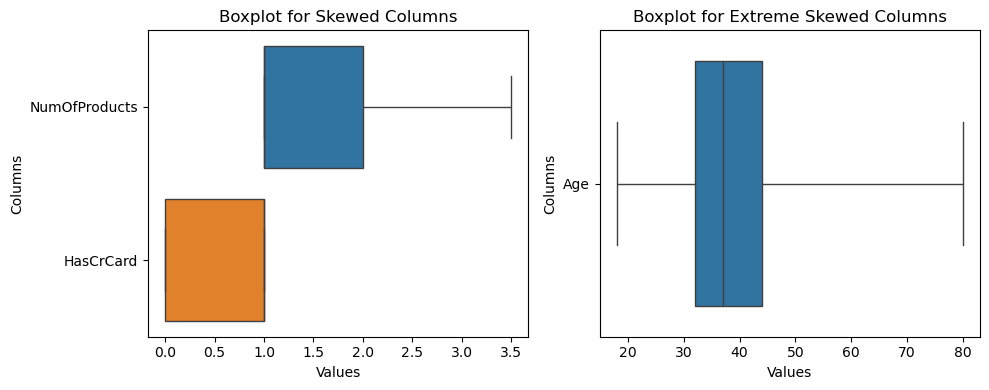

In [25]:
# Create a figure and two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Boxplot for skewed columns
sns.boxplot(data=X_train[skewed_columns], orient="h", ax=axes[0])
axes[0].set_title("Boxplot for Skewed Columns")
axes[0].set_xlabel("Values")
axes[0].set_ylabel("Columns")

# Boxplot for extreme skewed columns
sns.boxplot(data=X_train[extreme_skewed_columns], orient="h", whis=3, ax=axes[1])
axes[1].set_title("Boxplot for Extreme Skewed Columns")
axes[1].set_xlabel("Values")
axes[1].set_ylabel("Columns")

# Display the plot
plt.tight_layout()
plt.show()

Capping outliers telah dilakukan. Perbedaan paling jelas untuk skew dan extreme skew columns, misalnya kolom age yang tadinya memiliki nilai skewness 1.2 setelah di capping jadi 0.9, begitu juga dengan NumOfProducts dari 0.75 setelah di capping menjadi 0.56.

## Feature Scalling & Encoding

In [42]:
# Feature Scalling & Encoding
scaler = StandardScaler()
ore = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)

preprocess = ColumnTransformer(
    transformers = [
        ('num',scaler,num_cols),
        ('cat',ore,cat_cols)],
    remainder='passthrough')

# VI - Model Definition

In [43]:
# Model Definition menggunakan pipeline
pipe_log = make_pipeline(preprocess,LogisticRegression(max_iter=1000000))
pipe_svc = make_pipeline(preprocess,SVC(random_state=42))
pipe_dt = make_pipeline(preprocess,DecisionTreeClassifier(random_state=42))
pipe_rf = make_pipeline(preprocess,RandomForestClassifier(random_state=42))
pipe_knn = make_pipeline(preprocess,KNeighborsClassifier())
pipe_nb = make_pipeline(preprocess,GaussianNB())
pipe_ada = make_pipeline(preprocess,AdaBoostClassifier(random_state=42))

## Cross Validation

In [33]:
# setting kfold
skfold = StratifiedKFold(n_splits = 10)

# Define Cross Validation untuk semua model
cv_log_model = cross_val_score(pipe_log, X_train, y_train, cv = skfold, scoring='f1', n_jobs=-1)
cv_svm_model = cross_val_score(pipe_svc, X_train, y_train, cv = skfold, scoring='f1', n_jobs=-1)
cv_dt_model = cross_val_score(pipe_dt, X_train, y_train, cv = skfold, scoring='f1', n_jobs=-1)
cv_rf_model = cross_val_score(pipe_rf, X_train, y_train, cv = skfold, scoring='f1', n_jobs=-1)
cv_knn_model = cross_val_score(pipe_knn, X_train, y_train, cv = skfold, scoring='f1', n_jobs=-1)
cv_nb_model = cross_val_score(pipe_nb, X_train, y_train, cv = skfold, scoring='f1', n_jobs=-1)
cv_ada_model = cross_val_score(pipe_ada, X_train, y_train, cv = skfold, scoring='f1', n_jobs=-1)

Fokus scoring menggunakan F1-score diplih karena masing-masing baik false negative dan false positive memiliki dampak terhadap Bank.
- `False Negative`
Dimana model memprediksi bahwa nasabah akan bertahan tetapi malah keluar yang mana membuat bank kehilangan nasabah tanpa melakukan upaya untuk mempertahannya. Hal ini akan merugikan bank dari segi pendapatan dan pertumbuhan bisnis.

- `False Positive`
Perusahaan mungkin menghabiskan sumber daya untuk mempertahankan pelanggan yang sebenarnya tidak akan churn, tetapi ini masih lebih baik daripada kehilangan pelanggan tanpa upaya. Oleh karena itu, jika bank behasil membedakan nasabah yang bertahan dan keluar, upaya yang memerlukan sumber daya seperti dari segi ekonomis dan tenaga dapat di maksimalkan untuk nasabah yang di prediksi mau keluar saja.

In [34]:
# Mencari model terbaik berdasarkan hasil rata-rata Cross_Val_Score
name_model = []
cv_scores = 0
for cv,name in zip([cv_log_model,cv_svm_model,cv_dt_model,cv_rf_model,cv_knn_model,cv_nb_model,cv_ada_model],
                   ['log_model','svm_model','dt_model','rf_model','knn_model','nb_model','ada_model']):
  print(name)
  print('f1-score - All - Cross Validation :', cv)
  print('f1-score - Mean - Cross Validation :', cv.mean())
  print('f1-score - std - Cross Validation :', cv.std())
  print('f1-score - Range of Test Set :', (cv.mean()-cv.std()), '-' , (cv.mean()+cv.std()))
  print('-'*50)
  if cv.mean() > cv_scores:
    cv_scores = cv.mean()
    name_model = name
  else:
    pass
print('Best Model:', name_model)
print('Cross Val Mean from Best Model:', cv_scores)

log_model
f1-score - All - Cross Validation : [0.31818182 0.19323671 0.30222222 0.25352113 0.23923445 0.27488152
 0.24752475 0.31034483 0.31481481 0.32727273]
f1-score - Mean - Cross Validation : 0.27812349706378886
f1-score - std - Cross Validation : 0.04154001133828906
f1-score - Range of Test Set : 0.2365834857254998 - 0.3196635084020779
--------------------------------------------------
svm_model
f1-score - All - Cross Validation : [0.45689655 0.45762712 0.525      0.54098361 0.51612903 0.48192771
 0.57959184 0.57370518 0.45081967 0.525     ]
f1-score - Mean - Cross Validation : 0.510768070817573
f1-score - std - Cross Validation : 0.044940274517356035
f1-score - Range of Test Set : 0.465827796300217 - 0.5557083453349291
--------------------------------------------------
dt_model
f1-score - All - Cross Validation : [0.43450479 0.46857143 0.51497006 0.51744186 0.4601227  0.47159091
 0.53293413 0.51744186 0.44444444 0.50920245]
f1-score - Mean - Cross Validation : 0.48712246403602827

Dari score rata-rata yang di tampilkan oleh semua model yang telah di definisikan, model `random forest` memiliki nilai yang paling tinggi, sehingga di pilih sebagai best model.

# VII - Model Training

In [35]:
# Fit model pada data train
pipe_rf.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['CreditScore', 'Age',
                                                   'Tenure', 'Balance',
                                                   'NumOfProducts', 'HasCrCard',
                                                   'IsActiveMember',
                                                   'EstimatedSalary']),
                                                 ('cat',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['Geography', 'Gender'])])),
                ('randomforestclassifier',
                 RandomForestClassifier(random_state=42))])

## Pemodelan Sebelum Tunning

In [36]:
# Lakukan prediksi untuk data train dan test
y_pred_train = pipe_rf.predict(X_train)
y_pred_test = pipe_rf.predict(X_test)

In [37]:
# Print F1 score
print('F1 Score - Train Set  : ', f1_score(y_train, y_pred_train))
print('F1 Score - Test Set   : ', f1_score(y_test, y_pred_test))

F1 Score - Train Set  :  1.0
F1 Score - Test Set   :  0.6086956521739131


Pemodelan sebelum tunning sangat kontras perbedaannya antara train set dan test set, sekitar 40%. Keadaan diatas adalah overfitting pada train set, dan juga data tese dibawah treshold yaitu 75 - 80.

## Hyperparameter Tunning dengan Random Search

In [38]:
%%time
# Set up the parameter grid for Random Forest
param_grid_rf = {
    'randomforestclassifier__n_estimators': [300, 1200],
    'randomforestclassifier__max_depth': [None, 30, 40, 50],
    'randomforestclassifier__min_samples_split': [2, 5, 10],
    'randomforestclassifier__min_samples_leaf': [1, 2, 4],
    'randomforestclassifier__class_weight': ['balanced', 'balanced_subsample']
}

random_search_rf = RandomizedSearchCV(pipe_rf,
                                      param_distributions=param_grid_rf,
                                      cv=skfold,
                                      scoring='f1',
                                      n_jobs=-1,
                                      random_state=42)

# Fit GridSearchCV for Random Forest
random_search_rf.fit(X_train, y_train)

# Best hyperparameters for Random Forest
print('Best hyperparameters for Random Forest:', random_search_rf.best_params_)

# Best recall for Logistic Regression
print('Best f1 for Random Forest:', random_search_rf.best_score_)

# Save best Random Forest model to a variable
best_rf_model = random_search_rf.best_estimator_

Best hyperparameters for Random Forest: {'randomforestclassifier__n_estimators': 300, 'randomforestclassifier__min_samples_split': 2, 'randomforestclassifier__min_samples_leaf': 4, 'randomforestclassifier__max_depth': None, 'randomforestclassifier__class_weight': 'balanced'}
Best f1 for Random Forest: 0.6103785946254576
CPU times: total: 13.3 s
Wall time: 8min 28s


## Prediksi setelah dilakukan hyperparameter tunning

In [39]:
# Lakukan prediksi untuk data yang sudah di tuning
y_pred_train_tunned = best_rf_model.predict(X_train)
y_pred_test_tunned = best_rf_model.predict(X_test)

In [40]:
# Print f1 score
print('f1 Score - Train Set  : ', f1_score(y_train, y_pred_train_tunned))
print('f1 Score - Test Set   : ', f1_score(y_test, y_pred_test_tunned))

f1 Score - Train Set  :  0.874675885911841
f1 Score - Test Set   :  0.6326530612244898


Setelah dilakukannya hyperparameter tunning dengan menggunakan random search dan dilakukan prediksi, hasilnya improve dengan cukup baik disini, gap antara train dan test berkurang lumayan banyak.

Train set yang tadinya memiliki gap dengan test sebesar 40% karena scorenya 100, kini score Train meunurun ke 87% dan score test meningkat ke 63% menjadikan gap antara mereka menurun ke 24%. Memang kodnisi ini cukup baik, namun mengingat treshold yang saya gunakan adalah antara 75% - 80%, model ini dipastikan overfit.

In [41]:
# Save Model

with open('num_cols.txt', 'w') as file_1:
  json.dump(num_cols, file_1)

with open('cat_cols.txt', 'w') as file_2:
  json.dump(cat_cols, file_2)

with open('best_rf_model.pkl', 'wb') as file_3:
  pickle.dump(best_rf_model, file_3)

# XI - Conclusion

Dari hasil pemodelan ML untuk memprediksi nasabah yang memiliki niat untuk bertahan dan menutup akun, kemudian algoritma yang digunakan adalah `Random Forest`, dan scoring menggunakan F1-Score. Diketahui pemodelan mengguanakan sebelum tunning memiliki nilai yang kontras antara train dan test nya, lali di lakukanlah hyperparameter tunning menggunakan random search untuk efisiensi waktu saat ber eskperimen, di dapati nilai antara train dan test memiliki nilai gap yang lebih rapat sebesar 24% dengan score 86% untuk train dan 62% untuk test.

Meskipun terbilang cukup overfit untuk model kali ini, namun dari prediksi yang di jalankan pada model infrence menunjukan bahwa model ML yang saya buat mampu membedakan atau mengklasifikasi nasabah mana saja yang berpeluang untuk bertahan dan menutup akun bank mereka. Kedepannya, harapan saya model ini dapat ditingkatkan kembali untuk scorenya agar, model yang telah dibuat dapat memprediksi secara lebih akurat.